# Coffee-Seasonality ☕
### A frost can double the price overnight — so can you trade the calendar?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Frost premium?: Busted](https://img.shields.io/badge/Frost_premium%3F-Busted-8b949e?style=flat-square)

The story is irresistible: coffee is a Southern-Hemisphere crop, Brazil grows a third of the world's beans, and a single overnight frost in the Brazilian winter (Jun–Aug) can wipe out a harvest and send prices soaring. Surely you buy ahead of frost season and sell into the May–Sep harvest glut? We checked 26 years of Arabica futures. The answer is a flat no — and the reason is the very thing that makes the story exciting.

> **Plain-language layer.** The HAC t-stats, the bootstrap CI and the timer math are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Not investment advice. Every chart is generated by the code beside it; the cell banners say whether it is the real KC=F tape or the offline synthetic control.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (coffee_seasonality/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from coffee_seasonality import data, strategy as st

# Cache-first real tape; fall back to the synthetic control OFFLINE and banner which tape we show.
try:
    from quantlab import repro
    d = repro.as_of(data.fetch_data())   # cache-first (examples/verify.py --fetch)
    if d.empty:
        raise RuntimeError("cache miss")
    TAPE = "REAL  (KC=F monthly, 2000-02..2026-05, 316 months, fp 89301021ccad)"
except Exception as e:
    d, _ = data.synthetic_world(frost_premium=0.0, seed=307)  # the NULL synthetic world
    TAPE = f"SYNTHETIC NULL control (offline fallback: {e}) -- NOT the real tape"
print("TAPE:", TAPE)
rf = d["tbill"]
timer = st.seasonal_timer(d["coffee"], tbill=rf)
net   = st.apply_costs(timer, n_trades_per_year=4, cost_bps_one_way=10)
bh    = st.buy_hold(d["coffee"])
ms    = st.month_stats(d["coffee"])
fh    = st.frost_harvest_tstat(d["coffee"])


TAPE: REAL  (KC=F monthly, 2000-02..2026-05, 316 months, fp 89301021ccad)


## The answer first 🎯

| The claim | The data (KC=F, 2000–2026, 316 months) |
|---|---|
| "Frost season is reliably bullish" | Frost (Jun–Aug) mean **+0.43%**, harvest (May/Sep) −0.13%, spread **t = 0.34** — a coin flip, CI **[−3.5%, +4.5%]**. |
| "Trade it with a calendar rule" | Long-frost/short-harvest timer Sharpe **0.04** vs buy-and-hold **0.20** (excess of T-bill) — total destruction of edge. |
| "Every year" | The frost premium is *negative* in 2000–2012 and flips sign after. No month is significant; the most bullish month (Nov) isn't even part of the story. |

## 1 · The claim

Arabica coffee grows in the Southern Hemisphere, concentrated in Brazil. From June to August — the Brazilian winter — a cold snap in the highlands can freeze the trees and destroy the next crop; the 1975, 1994 and 2021 frosts all sent prices vertical. Meanwhile the main harvest runs May–September, flooding the market with fresh beans. So the folklore: **buy coffee into the frost-risk window, short it into the harvest glut.**

## 2 · So what?

If the calendar were real, you would not need to forecast the weather — you would just be long every June and short every September and collect a seasonal premium. Coffee is one of the most-traded soft commodities, so a reliable calendar edge would be worth real money. The catch: is the *average* June actually up, or do we just remember the years a frost hit?

## 3 · How would we even know?

We line up every January, every February, … and ask whether each month's average return is reliably different from zero (with an autocorrelation-robust t-stat). We compare the frost months (Jun–Aug) against the harvest shoulders (May/Sep) and put an honest confidence interval on the gap. Then we build the obvious calendar timer and race it against just buying and holding. **If the gap's confidence interval straddles zero and the timer loses to buy-and-hold, it's a mirage.**

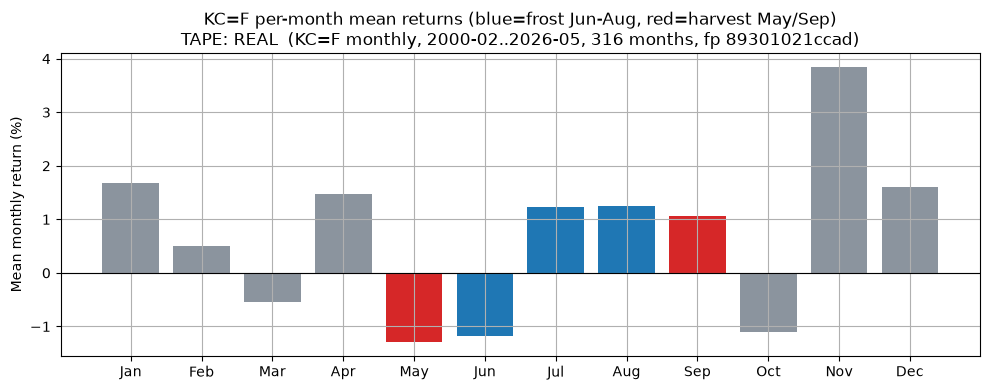

Frost (Jun-Aug): +0.43%  n=78
Harvest (May/Sep): -0.13%  n=53
Frost - Harvest spread: +0.57%  t=0.34


In [2]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
means = [ms.loc[m,'mean']*100 for m in range(1,13)]
tstats = [ms.loc[m,'tstat'] for m in range(1,13)]
frost = [6,7,8]; harvest=[5,9]
colors = []
for m in range(1,13):
    if abs(tstats[m-1])>=2: colors.append('#2ea44f')
    elif m in frost: colors.append('#1f77b4')
    elif m in harvest: colors.append('#d62728')
    else: colors.append('#8b949e')
fig,ax = plt.subplots(figsize=(10,4))
ax.bar(month_names, means, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean monthly return (%)')
ax.set_title(f'KC=F per-month mean returns (blue=frost Jun-Aug, red=harvest May/Sep)\nTAPE: {TAPE}')
plt.tight_layout(); plt.show()
print(f"Frost (Jun-Aug): {fh['frost_mean']*100:+.2f}%  n={fh['n_frost']}")
print(f"Harvest (May/Sep): {fh['harvest_mean']*100:+.2f}%  n={fh['n_harvest']}")
print(f"Frost - Harvest spread: {fh['spread']*100:+.2f}%  t={fh['tstat']:.2f}")

## 4 · The teardown — let's actually look

Look at the blue (frost) bars. June — the heart of the frost window — is the **single most negative month** on the chart. The frost-minus-harvest spread on the real tape is **+0.57%/month with t = 0.34**: indistinguishable from zero, and its confidence interval runs from **−3.5% to +4.5%**. The vivid frost story leaves no fingerprint in the *average* month, because frost is a rare tail event — it happens in a handful of years and the calendar can't tell you which.

,cagr,sharpe,max_drawdown
frost/harvest timer (gross),0.005,0.037,-0.751
timer (net 10bp/leg),0.001,0.017,-0.761
buy & hold KC=F,0.034,0.200,-0.693


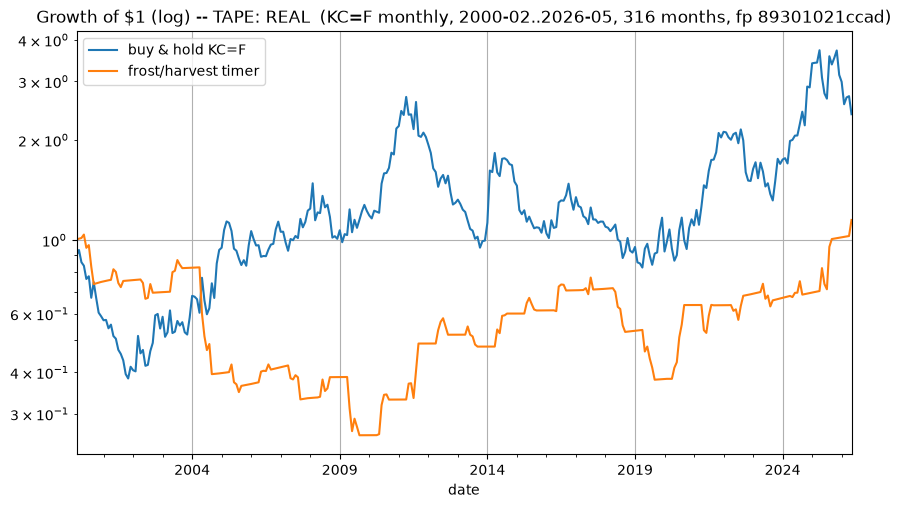

Sharpe = excess of T-bill, both legs, like-for-like


In [3]:
res = {
    'frost/harvest timer (gross)': st.summary(timer, rf=rf),
    'timer (net 10bp/leg)':        st.summary(net,   rf=rf),
    'buy & hold KC=F':             st.summary(bh,    rf=rf),
}
display(pd.DataFrame(res).T[['cagr','sharpe','max_drawdown']].round(3))
eq_bh = (1+bh).cumprod(); eq_t = (1+timer).cumprod()
ax = eq_bh.plot(label='buy & hold KC=F', lw=1.5)
eq_t.plot(ax=ax, label='frost/harvest timer', lw=1.5)
ax.set_yscale('log'); ax.legend()
ax.set_title(f'Growth of $1 (log) -- TAPE: {TAPE}'); plt.show()
print('Sharpe = excess of T-bill, both legs, like-for-like')

**Read it plainly.** The calendar timer turns an already-mediocre commodity into a worse one: Sharpe 0.04 against buy-and-hold's 0.20 on the real tape. Being short coffee in September is a great way to get run over by an occasional frost spike.

## 5 · The verdict

**Signal: None** — the frost-vs-harvest spread is t = 0.34 with a CI that straddles zero; no month is significant. **Tradability: Mirage** — the timer earns Sharpe 0.04 vs 0.20 for buy-and-hold. **"Frost premium"? Busted** — it's negative in the first half of the sample and flips sign after.

## 6 · Could you actually trade it?

No. You'd give back the entire (small) risk-adjusted return of just holding coffee, and costs only deepen the hole. The frost risk is real — but it's a weather lottery, not a date you can put in your calendar.

## 7 · Going further 🚪

Forks: (a) test a *frost-conditioned* rule using actual Brazilian minimum-temperature data instead of the calendar; (b) the harvest glut may show up in the futures *term structure* (contango/backwardation) rather than spot returns; (c) compare to [226 Crude-Seasonality](../../226-crude-seasonality/) — another commodity calendar that the desk found Weak/Mirage.